# Path Finder: What are the potential paths between two nodes?

This pipeline can be used to get a set of paths between nodes A and B, and rank the paths by various criteria.

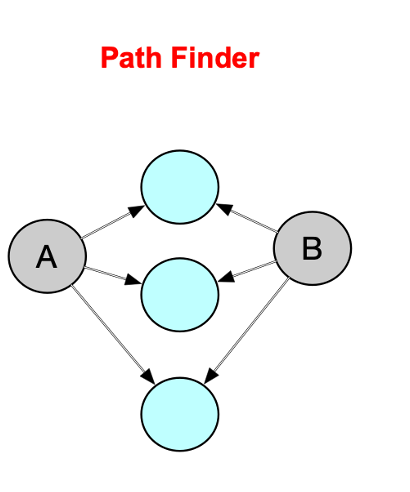


In [1]:
from TCT import TCT

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT_pathfinder


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import pandas as pd
import  seaborn as sns
import networkx as nx
import numpy as np
import ipycytoscape
import yaml


In [2]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

In [4]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)


(22147, 5)


In [20]:
name_resolver.lookup('miR-155')

TranslatorNode(curie='NCBIGene:114483536', label='MIR155', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin'], synonyms=None, curie_synonyms=None)

NCBIGene:3458
MONDO:0100096
'imProving Agent for TRAPI 1.5' generated an exception: argument of type 'NoneType' is not iterable
'Automat-ehr-may-treat-kp(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Multiomics KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'SPOKE KP for TRAPI 1.5' generated an exception: argument of type 'NoneType' is not iterable
'Microbiome KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'MolePro' generated an exception: argument of type 'NoneType' is not iterable
'Automat-pharos(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-icees-kg(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-monarchinitiative(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Connections Hypothesis Provider API' generated an exception: 'NoneType' object has no

/opt/miniconda3/envs/my-rdkit-env/lib/python3.13/site-packages/TCT/TCT.py:1508: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


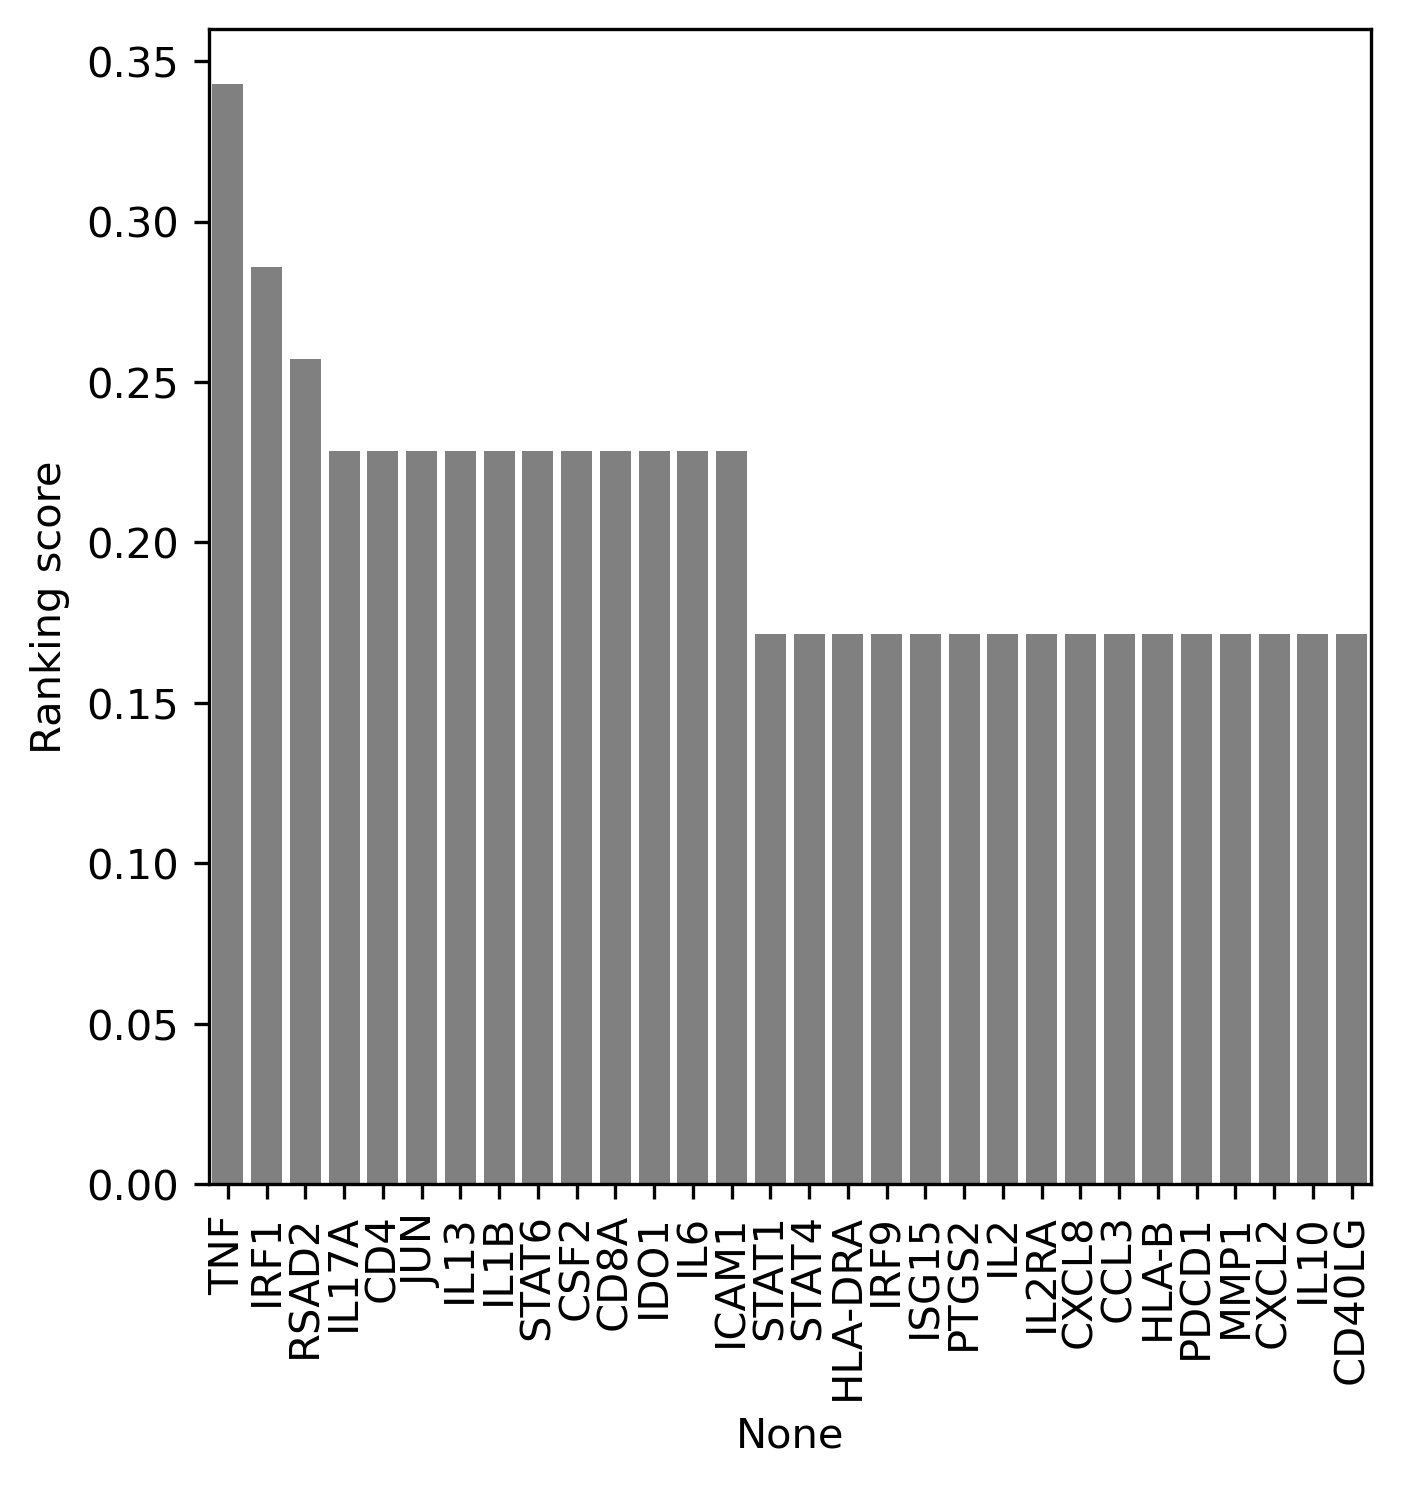

In [9]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder(input_node1='IFNG', 
                                                                                                                                                                                input_node2= 'COVID-19', 
                                                                                                                                                                                intermediate_categories=['biolink:Protein', 'biolink:Gene' ], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [ ]:
intermediate_node = name_resolver.lookup('IDO2').curie



In [75]:
matches2 = []
for k in result2.keys():
    if input_node2_id == result2[k]['subject'] and intermediate_node == result2[k]['object']:
        matches2.append(result2[k])
    elif input_node2_id == result2[k]['object'] and intermediate_node == result2[k]['subject']:
        matches2.append(result2[k])

for k in matches2:
    print(k['sources'])

[{'resource_id': 'infores:diseases', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:diseases']}]


In [46]:
matches = []
for k in result1.keys():
    if input_node1_id == result1[k]['subject'] and intermediate_node == result1[k]['object']:
        matches.append(result1[k])
    elif input_node1_id == result1[k]['object'] and intermediate_node == result1[k]['subject']:
        matches.append(result1[k])

for k in matches:
    print(k['sources'])

[{'resource_id': 'infores:string', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:monarchinitiative', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:string']}, {'resource_id': 'infores:service-provider-trapi', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:monarchinitiative']}]
[{'resource_id': 'infores:string', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:monarchinitiative', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:string']}, {'resource_id': 'infores:biothings-explorer', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:monarchinitiative']}]


In [ ]:


# Create a DataFrame from the matches
df = pd.DataFrame(matches)

# Display the DataFrame
df

,predicate,subject,object,attributes,sources
0,biolink:interacts_with,NCBIGene:169355,NCBIGene:3458,[{'attribute_type_id': 'biolink:knowledge_leve...,"[{'resource_id': 'infores:string', 'resource_r..."
1,biolink:interacts_with,NCBIGene:169355,NCBIGene:3458,[{'attribute_type_id': 'biolink:knowledge_leve...,"[{'resource_id': 'infores:string', 'resource_r..."


In [17]:
import lmstudio as lms
model = lms.llm("openai/gpt-oss-120b")
input_text = str(result1) + 'and '+str(result2)
question = "summarize the path that go over NCBIGene:23411 between NCBIGene:2739 and CHEBI:45713" 

In [22]:
result = model.respond("find the path between NPC1 and WNT7B" )

In [23]:
result

PredictionResult(content='<|channel|>analysis<|message|>We need to answer likely about a network of interactions? Provide path maybe gene interaction. Use known pathways: NPC1 interacts with cholesterol transport; WNT7B is ligand in Wnt signaling. Path could be via LDLR, β-catenin etc. Provide plausible molecular path.<|end|><|start|>assistant<|channel|>final<|message|>**Short answer:**  \nA biologically plausible route that connects the lysosomal‑cholesterol transporter **NPC1** to the secreted morphogen **WNT7B** runs through the intracellular cholesterol/oxysterol sensing machinery (SREBP‑2, LXRα/β) → transcriptional regulators of Wnt ligand expression (e.g.,\u202fTCF/LEF, β‑catenin) → a feedback loop that modulates WNT7B secretion.  \n\nBelow is a step‑by‑step “path” that stitches together the best‑supported molecular links from the literature and public interaction databases (STRING, BioGRID, Reactome, Gene Ontology).  Each edge is annotated with the type of evidence (physical bin

In [10]:
paths

,score,output_node,predictes1,predictes2,output_node_name
SIRT1,0.150,NCBIGene:23411,biolink:regulates; biolink:affects,biolink:affects; biolink:interacts_with; bioli...,SIRT1
HSPB1,0.150,NCBIGene:3315,biolink:physically_interacts_with; biolink:cor...,biolink:affected_by; biolink:occurs_together_i...,HSPB1
FLT1,0.150,NCBIGene:2321,biolink:interacts_with; biolink:regulates; bio...,biolink:affected_by; biolink:occurs_together_i...,FLT1
PTGS2,0.125,NCBIGene:5743,biolink:regulated_by,biolink:affected_by; biolink:affected_by; biol...,PTGS2
MAOA,0.100,NCBIGene:4128,biolink:interacts_with,biolink:affected_by; biolink:affected_by; biol...,MAOA
...,...,...,...,...,...
PLAUR,0.025,NCBIGene:5329,biolink:correlated_with,biolink:occurs_together_in_literature_with; bi...,PLAUR
RETN,0.025,NCBIGene:56729,biolink:correlated_with,biolink:occurs_together_in_literature_with; bi...,RETN
GABARAPL1,0.025,NCBIGene:23710,biolink:regulated_by,biolink:affected_by; biolink:affected_by,GABARAPL1
CES1,0.025,NCBIGene:1066,biolink:regulates; biolink:affects,biolink:affected_by; biolink:affected_by,CES1


In [36]:
paths

,score,output_node,predictes1,predictes2,output_node_name
SIRT1,0.150,NCBIGene:23411,biolink:affects; biolink:regulates,biolink:affects; biolink:interacts_with; bioli...,SIRT1
FLT1,0.150,NCBIGene:2321,biolink:directly_physically_interacts_with; bi...,biolink:occurs_together_in_literature_with; bi...,FLT1
HSPB1,0.150,NCBIGene:3315,biolink:correlated_with; biolink:physically_in...,biolink:occurs_together_in_literature_with; bi...,HSPB1
PTGS2,0.125,NCBIGene:5743,biolink:regulated_by,biolink:affected_by; biolink:occurs_together_i...,PTGS2
APP,0.100,NCBIGene:351,biolink:positively_correlated_with,biolink:interacts_with; biolink:occurs_togethe...,APP
...,...,...,...,...,...
CD244,0.025,NCBIGene:51744,biolink:correlated_with,biolink:affected_by; biolink:affected_by,CD244
BNIP3,0.025,NCBIGene:664,biolink:regulated_by,biolink:affected_by; biolink:affected_by; biol...,BNIP3
SERPINE1,0.025,NCBIGene:5054,biolink:regulated_by; biolink:correlated_with,biolink:occurs_together_in_literature_with; bi...,SERPINE1
PDGFA,0.025,NCBIGene:5154,biolink:correlated_with,biolink:occurs_together_in_literature_with; bi...,PDGFA


In [37]:
'NFE2L2' in paths['output_node_name']

True

In [11]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('HOXB7').curie, input_node2_id, result1, result2) 

CytoscapeWidget(cytoscape_layout={'name': 'cola', 'title': 'Path', 'nodeSpacing': 80, 'edgeLengthVal': 50}, cy…

CHEBI:83766
NCBIGene:672
'Text Mined Cooccurrence API' generated an exception: argument of type 'NoneType' is not iterable
'SPOKE KP for TRAPI 1.5' generated an exception: argument of type 'NoneType' is not iterable
'imProving Agent for TRAPI 1.5' generated an exception: argument of type 'NoneType' is not iterable
'MolePro' generated an exception: argument of type 'NoneType' is not iterable
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
'Automat-ehr-clinical-connections-kp(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Microbiome KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'Multiomics KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'Automat-ehr-may-treat-kp(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-ubergraph(Trapi v1.5.0)' generated an exception: 

/Users/guangrong/.pyenv/versions/3.12.1/lib/python3.12/site-packages/TCT/TCT.py:1517: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


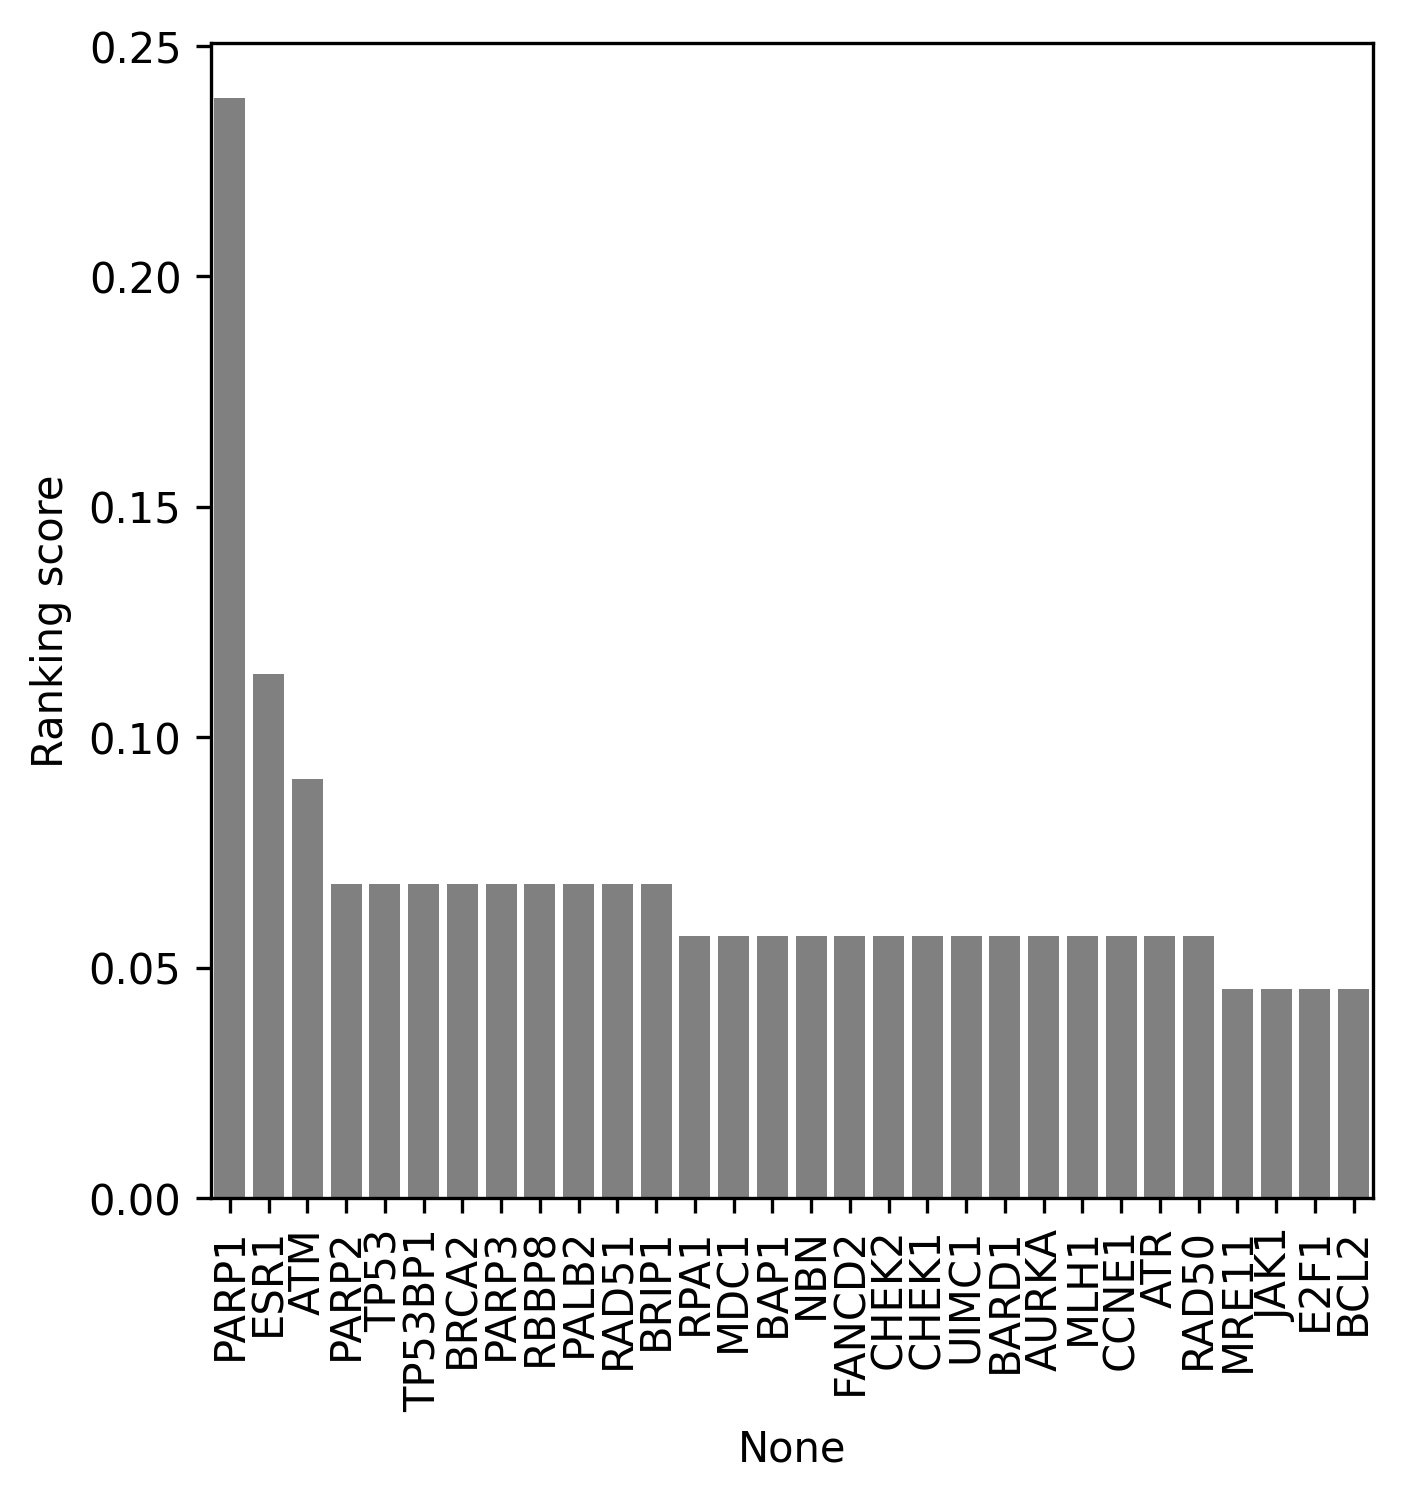

In [13]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder('Olaparib', 
                                                                                                                                                                                'BRCA1', 
                                                                                                                                                                                ['biolink:Gene', 'biolink:Protein'], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [48]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('IDO2').curie, input_node2_id, result1, result2) 

CytoscapeWidget(cytoscape_layout={'name': 'cola', 'title': 'Path', 'nodeSpacing': 80, 'edgeLengthVal': 50}, cy…

# link to the UI
https://ui.ci.transltr.io/
